In [1]:
import os
import pandas as pd
import pickle
from CADA.triples_gene_hpo import triples_gene_hpo
import networkx as nx
import numpy as np
from CADA.gae.preprocessing import mask_test_edges
from gensim.models import Word2Vec
from CADA.paths import DATA_DIRECTORY,MODEL_DIRECTORY

In [2]:
# Collect only gene-hpo term edges
gene_hpo_triples = triples_gene_hpo()
gene_hpo_edges = []
for triple in gene_hpo_triples:
    gene_hpo_edges.append((triple[0], triple[2]))
g_gene_hpo_edges = nx.Graph()
g_gene_hpo_edges.add_edges_from(gene_hpo_edges)
adj_sparse_gene_hpo_edges = nx.to_scipy_sparse_matrix(g_gene_hpo_edges)

# record gene nodes
nodes = list(g_gene_hpo_edges.nodes())
nodes_gene = []
for node in nodes:
    if node.startswith("Entrez:"):
        nodes_gene.append(node)

In [3]:
# get embeddings and create node embeddings matrix(rows = nodes, columns = embedding features)
model = Word2Vec.load('node2vec.model')
emb_mappings = model.wv


In [4]:
#count the number of training patients with a specific mutation for each mutation gene
train = os.path.join(os.getcwd(), 'patient_training.tsv')
if os.path.exists(train):
    train_pd = pd.read_csv(train, header=None, sep='\t', names=['patient_id', 'omim_id', 'gene_id', 'features', 'submitter',
                                    'from_file', 'no_features'])
    gene_counts = train_pd['gene_id'].value_counts().to_dict() 
else:
    gene_counts = {}

In [5]:
with open(os.path.join(DATA_DIRECTORY, 'processed', 'ids', 'gene_id_name.dict'), 'rb') as handle:
    gene_id_name = pickle.load(handle)

with open(os.path.join(DATA_DIRECTORY, 'processed', 'ids', 'hpo_id_name.dict'), 'rb') as handle:
    hpo_id_name = pickle.load(handle)

In [6]:
## Prioritizing genes for each test patient based on their hpo terms
with open('patient_testing.tsv', 'r') as t_file:
    content = t_file.read().splitlines()
    content = [x.split('\t') for x in content]
    evaluation_save = list()
    evaluation_vis = list()
    for line in content:
        prioritized_genelist = []
        patient_id = line[0]
        gene_id = line[2]
        # Get the number training patients with same mutation gene
        if gene_id in gene_counts:
            no_patients = gene_counts[gene_id]
        else:
            no_patients = 0
        # prioritize genes for each patients by computing the similarity between genes and hpo terms by dot product
        features = line[3].split(',')
        table = {}
        for gene in nodes_gene:
            sc_scores = []
            gene_emb = model.wv[gene]
            for feature in features:
                feature_emb = model.wv[feature]
                sc_score = np.dot(feature_emb, gene_emb)
                sc_scores.append(sc_score)
            table[gene] = sum(sc_scores)
        prioritized_genes = pd.DataFrame.from_dict(table, orient='index', columns=['score']).sort_values(by='score', ascending=False).index.values.tolist()
        # get the rank
        if gene_id in prioritized_genes:
            rank = prioritized_genes.index(gene_id) + 1
        else:
            rank = 'NA'
        evaluation_save.append([patient_id, gene_id, no_patients,','.join(features), prioritized_genes[:30], rank])
        evaluation_vis.append([patient_id, gene_id_name[gene_id], no_patients,
                                   ','.join([hpo_id_name[feature] for feature in features]), ','.join([gene_id_name[gene_id] for gene_id in prioritized_genes[:30]]), rank])
    # save the result
    saveframe = pd.DataFrame(evaluation_save, columns = ['patient_id', 'gene_id','no_patients', 'features', 'result', 'rank'])
    saveframe.to_csv('evaluation.tsv', sep='\t', index=None)
    visframe = pd.DataFrame(evaluation_vis, columns=['patient_id', 'gene', 'no_patients', 'features', 'result', 'rank'])
    visframe.to_excel('evaluation.xlsx', index=None) 
                
    

In [7]:
ranks = saveframe['rank'].tolist()
count1 = count5 = count10 = count50 = count100 = count1000 = 0
counts = len(ranks)
for rank in ranks:
    if isinstance(rank, int):
        if rank == 1:
            count1 += 1
        if rank <= 5:
            count5 += 1
        if rank <= 10:
            count10 += 1
        if rank <= 50:
            count50 += 1
        if rank <= 100:
            count100 += 1
        if rank <= 1000:
            count1000 += 1
top1 = round(count1/counts, 2)
top5 = round(count5/counts, 2)
top10 = round(count10/counts, 2)
top50 = round(count50/counts, 2)
top100 = round(count100/counts, 2)
top1000 = round(count1000/counts, 2)

print(f'top1: {top1}')
print(f'top5: {top5}')
print(f'top10: {top10}')
print(f'top50: {top50}')
print(f'top100: {top100}')
print(f'top1000: {top1000}')

top1: 0.06
top5: 0.15
top10: 0.22
top50: 0.46
top100: 0.56
top1000: 0.89


In [33]:
gene_rank = saveframe.groupby('gene_id')[['rank']].median().sort_values(by='rank')
gene_rank.columns = ['median_rank']
gene_rank

,median_rank
gene_id,
Entrez:4638,1.0
Entrez:4137,1.0
Entrez:2811,1.0
Entrez:5961,1.0
Entrez:2301,1.0
...,...
Entrez:200205,4053.0
Entrez:5921,4077.0
Entrez:142680,4207.0


In [48]:
gene_analysis = pd.read_csv('../descriptive_statistics/genes_hpo_disease_patient.csv', sep = '\t', index_col=0)

In [49]:
gene_table = pd.merge(gene_analysis, gene_rank, left_index=True, right_index=True, how='outer')

In [51]:
gene_table

,num_hpo_annotation,num_disease,num_patient,median_rank
Entrez:10000,28,1.0,1,360.0
Entrez:10002,46,2.0,2,45.0
Entrez:1001,48,2.0,1,54.0
Entrez:100151683,224,2.0,3,1116.0
Entrez:10020,100,2.0,2,2045.5
...,...,...,...,...
Entrez:9968,279,3.0,6,60.0
Entrez:998,131,1.0,2,579.5
Entrez:999,68,6.0,28,13.0
Entrez:9990,58,1.0,2,753.0


In [50]:
gna_row = gene_table[gene_table.isna().any(axis=1)]
na_row

,num_hpo_annotation,num_disease,num_patient,median_rank
Entrez:10529,8,NaN,1,274.0
Entrez:1761,4,NaN,1,253.0
Entrez:223117,15,NaN,1,2065.0
Entrez:23432,16,NaN,1,726.0
Entrez:23476,7,NaN,1,4236.0
Entrez:23512,41,NaN,1,523.0
Entrez:25802,15,NaN,1,12.0
Entrez:28514,33,NaN,1,1049.0
Entrez:4131,15,NaN,1,983.0
Entrez:4556,74,NaN,1,172.0


In [53]:
import seaborn as sns

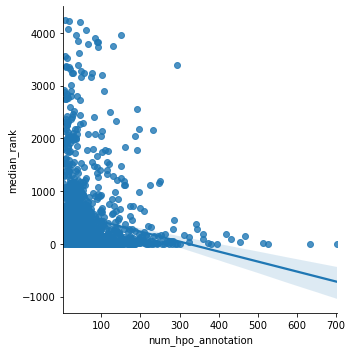

In [54]:
sns.lmplot(x='num_hpo_annotation', y='median_rank', data=gene_table, fit_reg=True)